# Health Insurance Cross Sell Prediction

This notebook performs an end-to-end data science project predicting whether health insurance customers will be interested in vehicle insurance. It includes data cleaning, EDA, visualization, preprocessing, and training/evaluating multiple models.

## 1. Introduction and Setup
Import necessary libraries.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Data Loading
Load the dataset from `train.csv`.

In [31]:
# Load the dataset
df = pd.read_csv('train.csv')

# Display the first few rows
df.head()

# Display basic information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


## 3. Data Cleaning
Check for missing values, duplicates, and fix data types if needed.

In [32]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Check for duplicates
print("\nNumber of duplicates:", df.duplicated().sum())

# Drop duplicates if any exist
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

# Drop the 'id' column as it's not useful for prediction
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)


Missing Values:
 id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

Number of duplicates: 0


## 4. Data Analysis (EDA) & Visualization
Explore the distribution of variables and their relationships.

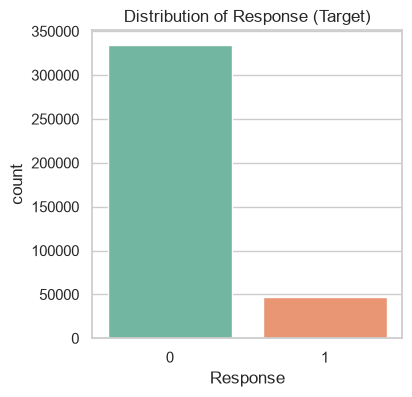

In [33]:
# Distribution of the Target Variable
plt.figure(figsize=(4,4))
sns.countplot(data=df, x='Response', palette='Set2')
plt.title('Distribution of Response (Target)')
plt.show()

# It is clear that the classes are highly imbalanced.

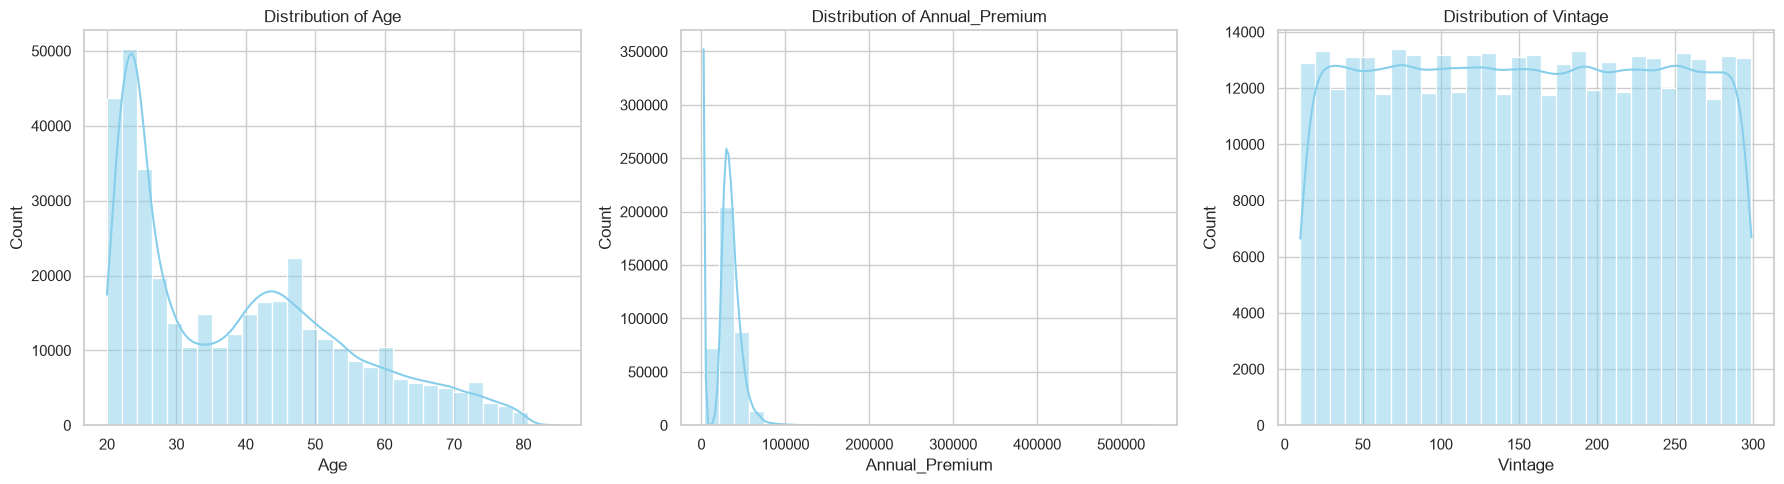

In [34]:
# Distribution of Numerical Features
num_cols = ['Age', 'Annual_Premium', 'Vintage']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

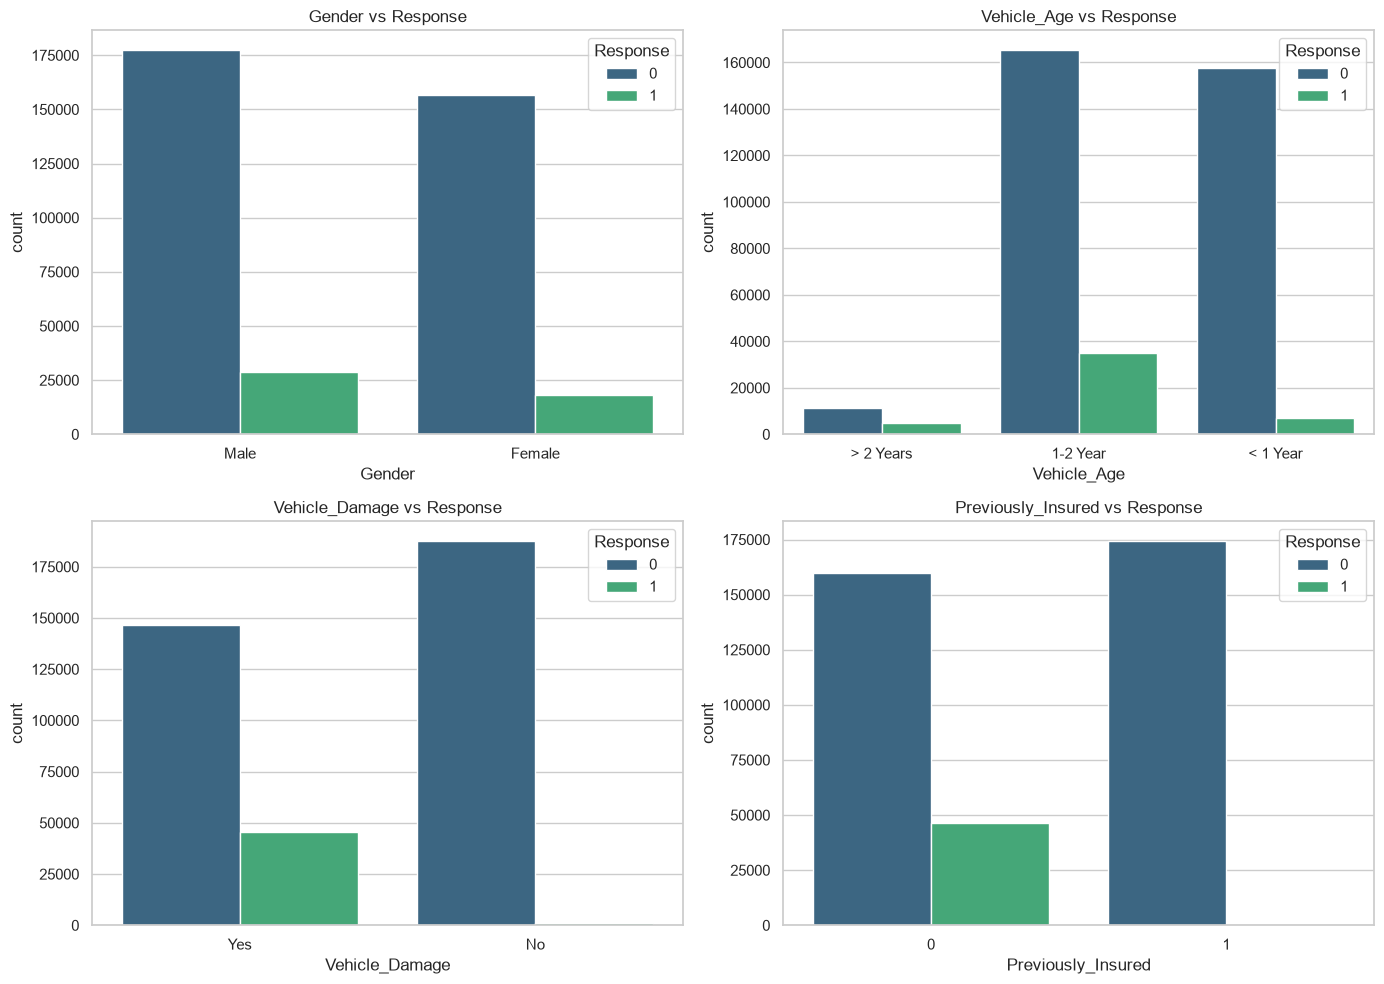

In [35]:
# Relationship between Categorical Features and Target
cat_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage', 'Previously_Insured']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Response', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Response')
plt.tight_layout()
plt.show()

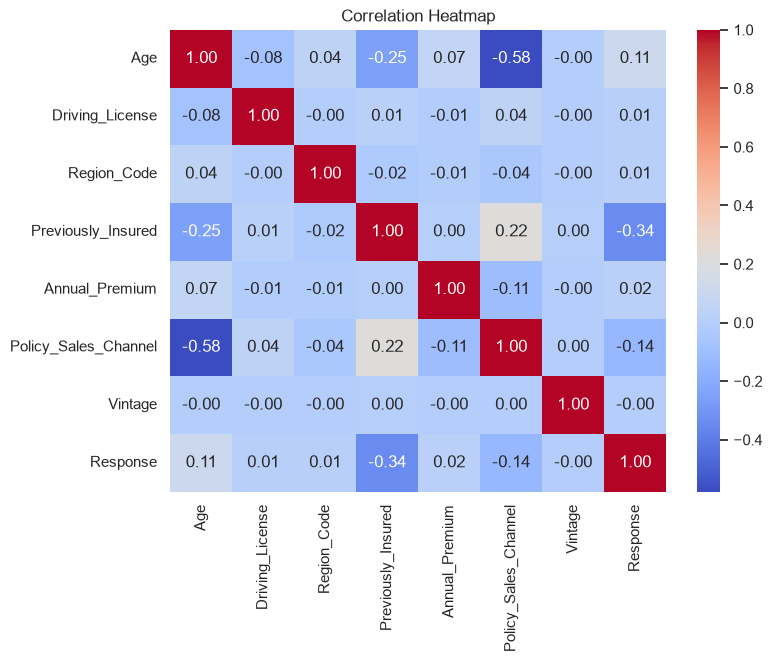

In [36]:
# Correlation Heatmap for Numerical variables
plt.figure(figsize=(8,6))
# Select only numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 5. Data Preprocessing
Encode categorical variables, split the dataset, and scale numerical variables. We will use a subset of the data if it's too large for quick training, or we can train on the whole thing. Given 380k rows, we'll train on a sample for faster execution, but you can change `sample_frac` to 1.0 to use all data.

In [37]:
# Encoding Categorical Variables
df_encoded = df.copy()

# Label Encoding for binary categories
le = LabelEncoder()
df_encoded['Gender'] = le.fit_transform(df_encoded['Gender']) # Male/Female -> 1/0
df_encoded['Vehicle_Damage'] = le.fit_transform(df_encoded['Vehicle_Damage']) # Yes/No -> 1/0

# Map Vehicle_Age manually to preserve order
age_map = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}
df_encoded['Vehicle_Age'] = df_encoded['Vehicle_Age'].map(age_map)

# One-hot encoding for Region_Code and Policy_Sales_Channel could be done, but they have many unique values.
# For simplicity and tree-based models, leaving them as integers is often fine.

# Separate Features (X) and Target (y)
X = df_encoded.drop('Response', axis=1)
y = df_encoded['Response']

# We will use the entire dataset instead of a subset to maximize performance
print(f"Training on the full dataset of shape: {X.shape}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Feature Scaling
# We scale only the continuous numerical variables to preserve categorical encodings
scaler = StandardScaler()
cols_to_scale = ['Age', 'Annual_Premium', 'Vintage']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on training data and transform both train and test sets
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Data preprocessing complete.")

Training on the full dataset of shape: (381109, 10)
Data preprocessing complete.


## 6. Model Training
Train Logistic Regression, Random Forest, and XGBoost models.

In [38]:
# Calculate scale_pos_weight for XGBoost to handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize models with class weights and tuned hyperparameters
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss', learning_rate=0.1, n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.\n")

Training Logistic Regression...
Logistic Regression trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training XGBoost...
XGBoost trained successfully.



## 7. Evaluation & Comparison
Compare the performance of the models using multiple metrics.

In [39]:
results = []

for name, model in trained_models.items():
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# Convert results to DataFrame for nice display
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,XGBoost,0.712904,0.288223,0.913509,0.438192,0.857514
1,Random Forest,0.698932,0.280449,0.930208,0.430966,0.855918
0,Logistic Regression,0.640222,0.251108,0.976343,0.399474,0.834337


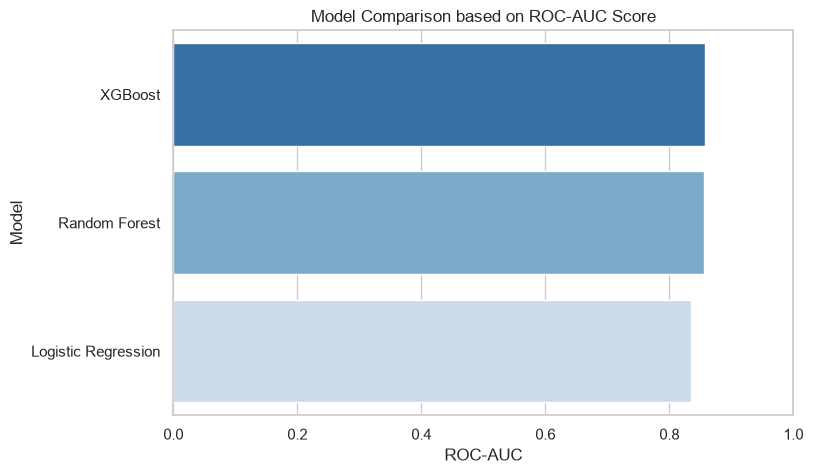

In [40]:
# Visualizing Model Comparison (ROC-AUC)
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x='ROC-AUC', y='Model', palette='Blues_r')
plt.title('Model Comparison based on ROC-AUC Score')
plt.xlim(0, 1)
plt.show()

### Conclusion
- You have successfully completed Data Cleaning, EDA, Preprocessing, and Model Evaluation.
- We can observe which model performs best in terms of ROC-AUC. Since the data is imbalanced, ROC-AUC and F1-score are much better metrics to look at than Accuracy.